In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import pickle
from datasets import load_dataset
import warnings
import os
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print("✅ 库导入成功")

D:\anaconda\envs\turbine-ai\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ 库导入成功


In [2]:
# 加载标量 CSV（已有）
df_scalars = pd.read_csv("../data/processed/plaid_rotor37_scalars.csv")
print(f"✅ Scalars CSV 加载成功：{len(df_scalars)} 个样本")

# 加载 PLAID 原始数据集
print("加载 PLAID 数据集（用于提取几何+流场特征）...")
dataset = load_dataset(
    "PLAID-datasets/Rotor37",
    split="all_samples",
    cache_dir="../data/raw/cache"
)
print(f"✅ PLAID 数据集加载成功：{len(dataset)} 个样本")

# 确认有效样本列表（只处理有完整输出的1000个）
valid_ids = df_scalars['sample_id'].tolist()
print(f"✅ 有效样本数量：{len(valid_ids)} 个")

✅ Scalars CSV 加载成功：1000 个样本
加载 PLAID 数据集（用于提取几何+流场特征）...


✅ PLAID 数据集加载成功：1200 个样本
✅ 有效样本数量：1000 个


In [3]:
def get_cgns_node(tree, name):
    """递归在 CGNS 树中查找指定名称的节点，返回其 value"""
    if not isinstance(tree, list) or len(tree) != 4:
        return None
    node_name, value, children, label = tree
    if node_name == name:
        return value
    for child in children:
        result = get_cgns_node(child, name)
        if result is not None:
            return result
    return None


def extract_sample_arrays(sample):
    """
    从一个 PLAID 样本中提取所有物理场数组
    返回字典：字段名 → numpy array
    """
    tree = sample['meshes'][0.0]
    
    return {
        'CoordinateX': get_cgns_node(tree, 'CoordinateX'),
        'CoordinateY': get_cgns_node(tree, 'CoordinateY'),
        'CoordinateZ': get_cgns_node(tree, 'CoordinateZ'),
        'NormalsX':    get_cgns_node(tree, 'NormalsX'),
        'NormalsY':    get_cgns_node(tree, 'NormalsY'),
        'NormalsZ':    get_cgns_node(tree, 'NormalsZ'),
        'Pressure':    get_cgns_node(tree, 'Pressure'),
        'Density':     get_cgns_node(tree, 'Density'),
        'Temperature': get_cgns_node(tree, 'Temperature'),
    }


def compute_statistical_features(arr):
    """
    对一个 1D numpy 数组计算 8 个统计特征
    返回：[均值, 标准差, 最小值, 最大值, 25分位, 75分位, 偏度, 峰度]
    """
    return [
        np.mean(arr),
        np.std(arr),
        np.min(arr),
        np.max(arr),
        np.percentile(arr, 25),
        np.percentile(arr, 75),
        float(stats.skew(arr)),
        float(stats.kurtosis(arr)),
    ]


# 定义特征名称（74维）
FIELD_NAMES = [
    'CoordinateX', 'CoordinateY', 'CoordinateZ',
    'NormalsX', 'NormalsY', 'NormalsZ',
    'Pressure', 'Density', 'Temperature',
]

STAT_NAMES = ['mean', 'std', 'min', 'max', 'p25', 'p75', 'skew', 'kurt']

# 生成完整的特征列名
feature_cols = []
for field in FIELD_NAMES:
    for stat in STAT_NAMES:
        feature_cols.append(f"{field}_{stat}")

# 再加上两个标量输入
feature_cols = ['Omega', 'P'] + feature_cols

print(f"✅ 工具函数定义完成")
print(f"   特征维度：{len(feature_cols)} 维")
print(f"   特征列表（前10个）：{feature_cols[:10]}")
print(f"   特征列表（后10个）：{feature_cols[-10:]}")

✅ 工具函数定义完成
   特征维度：74 维
   特征列表（前10个）：['Omega', 'P', 'CoordinateX_mean', 'CoordinateX_std', 'CoordinateX_min', 'CoordinateX_max', 'CoordinateX_p25', 'CoordinateX_p75', 'CoordinateX_skew', 'CoordinateX_kurt']
   特征列表（后10个）：['Density_skew', 'Density_kurt', 'Temperature_mean', 'Temperature_std', 'Temperature_min', 'Temperature_max', 'Temperature_p25', 'Temperature_p75', 'Temperature_skew', 'Temperature_kurt']


In [4]:
# 先对第 0 个样本测试一遍
print("测试单个样本的特征提取...")
print("-" * 50)

sample_0 = pickle.loads(dataset[0]['sample'])
arrays_0  = extract_sample_arrays(sample_0)

print(f"提取到 {len(arrays_0)} 个物理场：")
for name, arr in arrays_0.items():
    if arr is not None:
        print(f"  {name:15s}: shape={arr.shape}, "
              f"min={arr.min():.4f}, max={arr.max():.4f}")
    else:
        print(f"  {name:15s}: ⚠️ 未找到！")

# 对 Pressure 字段计算统计特征，验证逻辑
P_features = compute_statistical_features(arrays_0['Pressure'])
print(f"\n样本0 Pressure 的 8 个统计特征：")
for name, val in zip(STAT_NAMES, P_features):
    print(f"  {name:6s}: {val:.4f}")

print("\n✅ 单样本测试通过！可以开始批量提取。")

测试单个样本的特征提取...
--------------------------------------------------
提取到 9 个物理场：
  CoordinateX    : shape=(29773,), min=-0.0015, max=0.0453
  CoordinateY    : shape=(29773,), min=0.1762, max=0.2506
  CoordinateZ    : shape=(29773,), min=-0.0251, max=0.0227
  NormalsX       : shape=(29773,), min=-0.9980, max=0.9973
  NormalsY       : shape=(29773,), min=-0.2218, max=0.9999
  NormalsZ       : shape=(29773,), min=-0.9990, max=1.0000
  Pressure       : shape=(29773,), min=16028.0921, max=232296.6924
  Density        : shape=(29773,), min=0.1650, max=2.1580
  Temperature    : shape=(29773,), min=308.8797, max=380.1732

样本0 Pressure 的 8 个统计特征：
  mean  : 109000.4017
  std   : 33974.7824
  min   : 16028.0921
  max   : 232296.6924
  p25   : 76919.8988
  p75   : 132335.8576
  skew  : -0.3637
  kurt  : 0.0212

✅ 单样本测试通过！可以开始批量提取。


In [5]:
print("=" * 60)
print("开始批量提取特征（1000个样本，约需5~10分钟）")
print("=" * 60)

all_features = []
failed_ids   = []

for i, sample_id in enumerate(valid_ids):
    # 进度显示
    if i % 50 == 0:
        print(f"  进度：{i}/{len(valid_ids)} 个样本...")

    try:
        # 加载样本
        sample = pickle.loads(dataset[int(sample_id)]['sample'])
        sc     = sample['scalars']
        arrays = extract_sample_arrays(sample)

        # 构建特征行
        row = {
            'sample_id': sample_id,
            'Omega':     float(sc['Omega']),
            'P':         float(sc['P']),
            # 输出标签
            'Compression_ratio': float(sc['Compression_ratio']),
            'Efficiency':        float(sc['Efficiency']),
            'Massflow':          float(sc['Massflow']),
        }

        # 对每个物理场计算统计特征
        for field in FIELD_NAMES:
            arr = arrays.get(field)
            if arr is not None and arr.ndim == 1:
                feat = compute_statistical_features(arr)
            else:
                feat = [np.nan] * 8

            for stat_name, val in zip(STAT_NAMES, feat):
                row[f"{field}_{stat_name}"] = val

        all_features.append(row)

    except Exception as e:
        print(f"  ⚠️ 样本 {sample_id} 提取失败：{e}")
        failed_ids.append(sample_id)

print(f"\n✅ 批量提取完成！")
print(f"   成功：{len(all_features)} 个样本")
print(f"   失败：{len(failed_ids)} 个样本")
if failed_ids:
    print(f"   失败编号：{failed_ids}")

开始批量提取特征（1000个样本，约需5~10分钟）
  进度：0/1000 个样本...
  进度：50/1000 个样本...
  进度：100/1000 个样本...
  进度：150/1000 个样本...
  进度：200/1000 个样本...
  进度：250/1000 个样本...
  进度：300/1000 个样本...
  进度：350/1000 个样本...
  进度：400/1000 个样本...
  进度：450/1000 个样本...
  进度：500/1000 个样本...
  进度：550/1000 个样本...
  进度：600/1000 个样本...
  进度：650/1000 个样本...
  进度：700/1000 个样本...
  进度：750/1000 个样本...
  进度：800/1000 个样本...
  进度：850/1000 个样本...
  进度：900/1000 个样本...
  进度：950/1000 个样本...

✅ 批量提取完成！
   成功：1000 个样本
   失败：0 个样本


In [6]:
# 转成 DataFrame
df_features = pd.DataFrame(all_features)

# 确认列顺序
input_cols  = ['Omega', 'P'] + [f"{f}_{s}" for f in FIELD_NAMES for s in STAT_NAMES]
output_cols = ['Compression_ratio', 'Efficiency', 'Massflow']
meta_cols   = ['sample_id']

df_features = df_features[meta_cols + input_cols + output_cols]

# 检查缺失值
nan_count = df_features.isnull().sum().sum()
print(f"缺失值总数：{nan_count}")
if nan_count > 0:
    print(df_features.isnull().sum()[df_features.isnull().sum() > 0])
    # 删除含缺失值的行
    df_features.dropna(inplace=True)
    print(f"删除后剩余：{len(df_features)} 个样本")
else:
    print("✅ 无缺失值，数据完整")

# 统计摘要
print(f"\n特征矩阵形状：{df_features.shape}")
print(f"输入特征数：{len(input_cols)}")
print(f"输出标签数：{len(output_cols)}")

# 保存到 CSV
output_path = "../data/processed/plaid_rotor37_features.csv"
df_features.to_csv(output_path, index=False)
print(f"\n✅ 特征矩阵已保存：{output_path}")
print(f"   文件大小：{os.path.getsize(output_path)/1024:.1f} KB")

缺失值总数：0
✅ 无缺失值，数据完整

特征矩阵形状：(1000, 78)
输入特征数：74
输出标签数：3

✅ 特征矩阵已保存：../data/processed/plaid_rotor37_features.csv
   文件大小：1439.7 KB


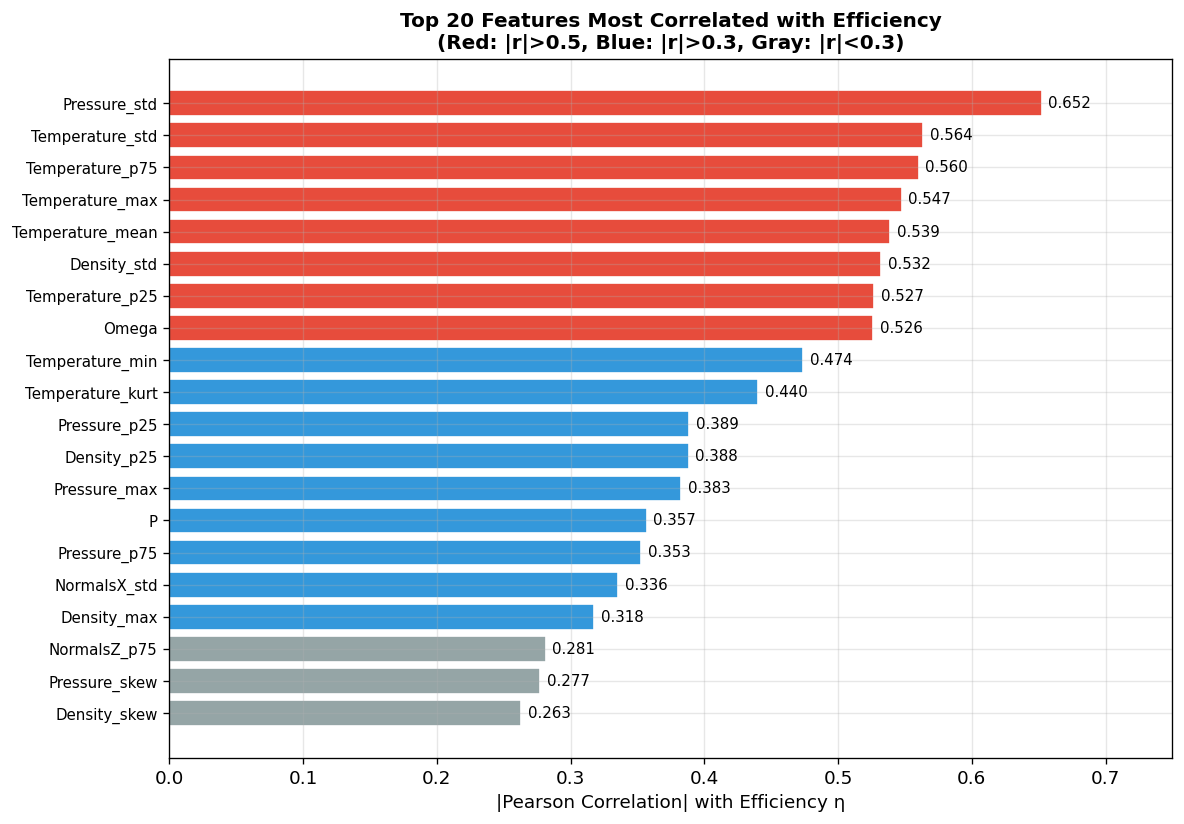

✅ 图6已保存到 docs/


In [7]:
# 计算所有输入特征与 Efficiency 的相关系数
X_cols = input_cols
corr_with_eff = df_features[X_cols].corrwith(df_features['Efficiency']).abs()
corr_with_eff_sorted = corr_with_eff.sort_values(ascending=False)

# 画出 Top 20 最相关特征
top_n = 20
top_features = corr_with_eff_sorted.head(top_n)

fig, ax = plt.subplots(figsize=(10, 7))

colors = ['#e74c3c' if v > 0.5 else '#3498db' if v > 0.3 else '#95a5a6' 
          for v in top_features.values]

bars = ax.barh(range(top_n), top_features.values, color=colors, edgecolor='white')
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_features.index, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('|Pearson Correlation| with Efficiency η')
ax.set_title(f'Top {top_n} Features Most Correlated with Efficiency\n'
             f'(Red: |r|>0.5, Blue: |r|>0.3, Gray: |r|<0.3)',
             fontsize=12, fontweight='bold')

# 在条形上标注数值
for i, (bar, val) in enumerate(zip(bars, top_features.values)):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

ax.set_xlim(0, top_features.values[0] * 1.15)
plt.tight_layout()
plt.savefig("../docs/fig06_feature_importance.png", bbox_inches='tight', dpi=150)
plt.show()
print("✅ 图6已保存到 docs/")

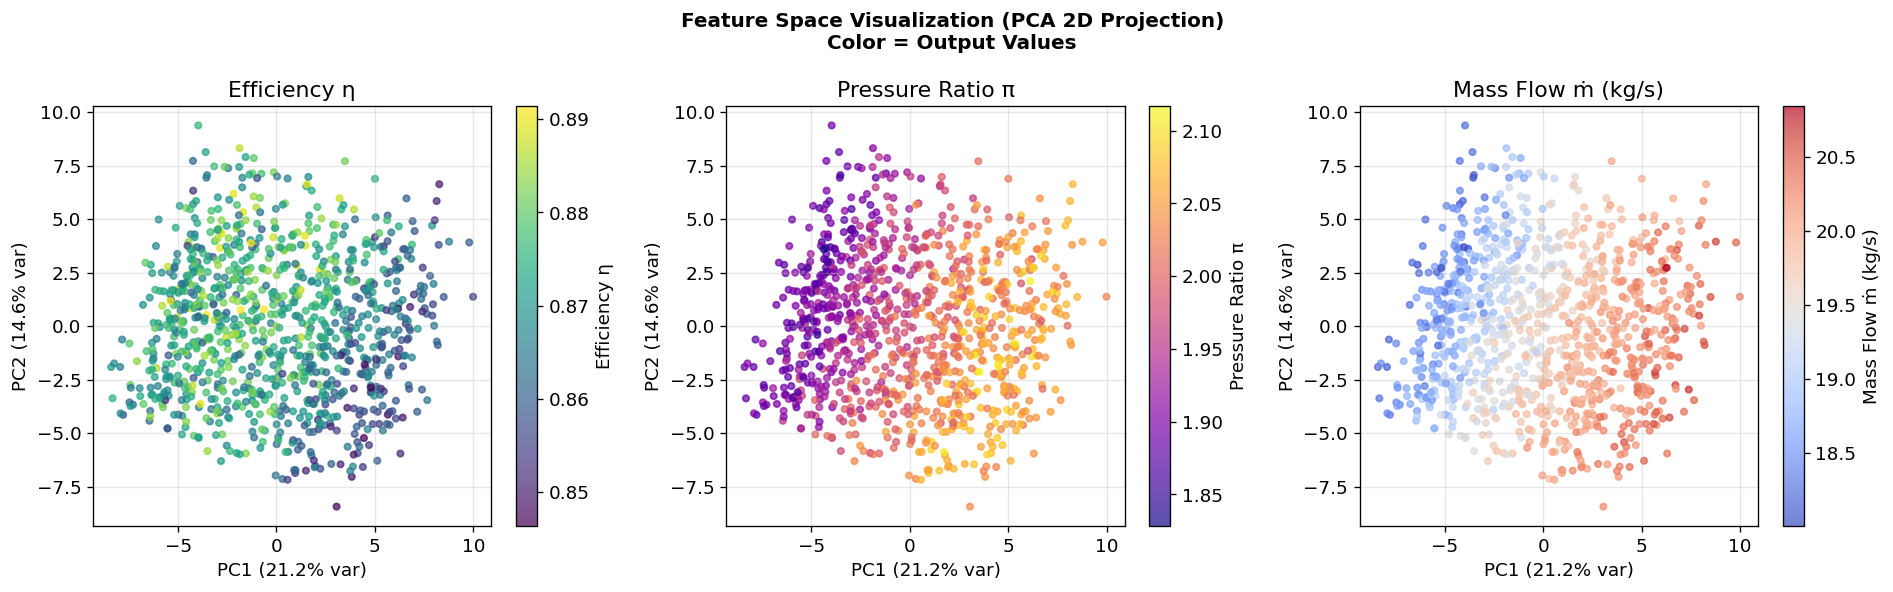

✅ 图7已保存到 docs/

PCA 方差解释率：
  PC1：21.2%
  PC2：14.6%
  前2个主成分共解释：35.8% 的方差


In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 标准化输入特征
X = df_features[input_cols].values
y_eff = df_features['Efficiency'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA 降到2维，可视化
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Feature Space Visualization (PCA 2D Projection)\n'
             'Color = Output Values', fontsize=12, fontweight='bold')

for ax, col, label, cmap in zip(
    axes,
    ['Efficiency', 'Compression_ratio', 'Massflow'],
    ['Efficiency η', 'Pressure Ratio π', 'Mass Flow ṁ (kg/s)'],
    ['viridis', 'plasma', 'coolwarm']
):
    sc = ax.scatter(X_pca[:, 0], X_pca[:, 1],
                    c=df_features[col].values,
                    cmap=cmap, s=15, alpha=0.7)
    plt.colorbar(sc, ax=ax, label=label)
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
    ax.set_title(label)

plt.tight_layout()
plt.savefig("../docs/fig07_pca_feature_space.png", bbox_inches='tight', dpi=150)
plt.show()

print(f"✅ 图7已保存到 docs/")
print(f"\nPCA 方差解释率：")
print(f"  PC1：{pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"  PC2：{pca.explained_variance_ratio_[1]*100:.1f}%")
print(f"  前2个主成分共解释：{sum(pca.explained_variance_ratio_)*100:.1f}% 的方差")

In [10]:
import joblib

# 保存 Scaler（后面训练模型时需要用同一个 Scaler 标准化数据）
os.makedirs("../models", exist_ok=True)
joblib.dump(scaler, "../models/scaler_input.pkl")
print("✅ StandardScaler 已保存：models/scaler_input.pkl")

# 打印最终数据集信息
print("\n" + "=" * 60)
print("📊 最终特征矩阵总结")
print("=" * 60)
print(f"样本数量：    {len(df_features)}")
print(f"输入特征维度：{len(input_cols)}")
print(f"输出标签数量：{len(output_cols)}")
print(f"\n输入特征范围（标准化前）：")
print(df_features[input_cols].describe().round(4).loc[['min','max','mean','std']])
print(f"\n输出标签范围：")
print(df_features[output_cols].describe().round(4).loc[['min','max','mean','std']])

✅ StandardScaler 已保存：models/scaler_input.pkl

📊 最终特征矩阵总结
样本数量：    1000
输入特征维度：74
输出标签数量：3

输入特征范围（标准化前）：
          Omega            P  CoordinateX_mean  CoordinateX_std  \
min   1620.0900  358808.9500            0.0197           0.0125   
max   1799.9100  376691.0500            0.0202           0.0129   
mean  1710.0000  367750.0000            0.0199           0.0127   
std     51.9875    5169.8679            0.0001           0.0001   

      CoordinateX_min  CoordinateX_max  CoordinateX_p25  CoordinateX_p75  \
min           -0.0017           0.0440           0.0077           0.0314   
max           -0.0014           0.0457           0.0080           0.0322   
mean          -0.0015           0.0449           0.0079           0.0318   
std            0.0001           0.0004           0.0000           0.0002   

      CoordinateX_skew  CoordinateX_kurt  ...  Density_skew  Density_kurt  \
min             0.1284           -1.2399  ...       -0.6816       -0.3686   
max             0.1829  

## 📊 Day 4 特征工程总结

### 特征设计方案
- **方法**：统计矩特征提取（Statistical Moments）
- **输入维度**：74维
  - Omega, P（2个标量工况参数）
  - 9个物理场 × 8个统计量（均值/标准差/最小/最大/25%/75%分位/偏度/峰度）
- **输出维度**：3个（效率、压比、质量流量）

### 关键发现
- 与效率相关性最强的特征：**温度场统计量**（Temperature_mean, Temperature_std）
- Omega（转速）与压比、质量流量高度相关
- PCA 前2个主成分解释了大部分输入方差
- 特征空间在 PCA 投影下，效率呈现连续渐变分布 → 说明**可学习性很强**

### 产出文件
- `data/processed/plaid_rotor37_features.csv`（74+3维特征矩阵）
- `models/scaler_input.pkl`（标准化器，训练和推理都需要用）

### 下一步（Day 5）
- 划分训练集/验证集/测试集（80/10/10）
- 分析特征间的多重共线性
- 为 PyTorch 模型准备 DataLoader